# Modelo final XGBoost — Predicción diaria de PM10

Este notebook construye el dataset de modelización y desarrolla el modelo de
predicción de PM10 en un único documento, sustituyendo a los notebooks
`01_construccion_dataset.ipynb` y `02_modelado_xgboost.ipynb`.

## 1. Planteamiento

**Escenario temporal — horizonte de un día.** Para predecir la concentración
media diaria de PM10 del día `T + 1` en cada estación de calidad del aire de
Madrid, el modelo utiliza únicamente información observada disponible hasta el
cierre del día `T`.

- **Meteorología, histórico de otros contaminantes e histórico del propio PM10**
  se toman en `T`, `T − 1` y `T − 6`, y las **medias móviles** de 3 y 7 días
  terminan en `T`.
- **El calendario del día objetivo `T + 1`** (laborable / no laborable, mes) se
  conoce de antemano, así que se toma directamente de `T + 1`.
- **Target:** PM10 del día `T + 1`.

Bloques de variables (el conjunto acordado con el equipo):

- **Histórico del propio contaminante:** `PM10_t`, `PM10_lag1`, `PM10_lag6`,
  `PM10_ma3`, `PM10_ma7` en la propia estación (`lag1` = `T − 1`,
  `lag6` = `T − 6`).
- **Histórico de otros contaminantes:** los mismos retardos y medias de NO2, O3
  y PM2.5, sobre la media diaria de Madrid (solo estaciones que miden cada uno).
- **Meteorología (`_t`):** todas las variables de `meteo_final` observadas en el
  día `T`, asignando a cada estación de aire la estación meteo más cercana
  **por variable**.
- **Calendario del día objetivo `T + 1`:** condición de día laborable y
  codificación cíclica del mes (`mes_sin`, `mes_cos`).
- **Estación:** latitud, longitud, altitud y tipo de estación (tráfico / fondo).
  El identificador numérico de estación no se usa como predictor.

> La asignación de la estación meteo más cercana por variable se resuelve en SQL
> sobre `distancias_meteo` (dimensión de estaciones de aire).

La metodología de modelado se mantiene respecto a `02_modelado_xgboost.ipynb`:
baseline de persistencia, búsqueda de hiperparámetros con *early stopping*,
selección de variables por eliminación progresiva, segunda rejilla de
regularización, y evaluación final única sobre 2024. Métricas: **MAE**
(principal), RMSE, R2 y **sesgo medio**.

## 2. Configuración e importación de librerías

In [1]:
# ============================================================
# IMPORTS Y CONFIGURACIÓN
# ============================================================

from pathlib import Path
import json
import warnings
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import duckdb

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

In [2]:
# ============================================================
# LOCALIZACIÓN DEL PROYECTO Y CONEXIÓN A DUCKDB
# ============================================================

ROOT = Path.cwd()

while not (ROOT / "src" / "database" / "TFM.duckdb").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("No se ha encontrado src/database/TFM.duckdb")
    ROOT = ROOT.parent

DB_PATH = ROOT / "src" / "database" / "TFM.duckdb"

# Solo lectura: desde modelado no se modifican los datos de la ETL.
con = duckdb.connect(str(DB_PATH), read_only=True)

print("Raíz del proyecto:", ROOT)
print("Base de datos:", DB_PATH)

Raíz del proyecto: c:\Users\evagd\OneDrive\Documentos\Master\TFM\Report\TFM
Base de datos: c:\Users\evagd\OneDrive\Documentos\Master\TFM\Report\TFM\src\database\TFM.duckdb


### Parámetros del modelo

`CONTAMINANTE` fija el objetivo del notebook. `MAGNITUDES_CONTEXTO` recoge los
**otros** contaminantes que se usan como contexto atmosférico común (todos
salvo el objetivo).

In [3]:
# ============================================================
# PARÁMETROS
# ============================================================

MAGNITUDES = {"NO2": 8, "PM2.5": 9, "PM10": 10, "O3": 14}

CONTAMINANTE = "PM10"
MAGNITUD = MAGNITUDES[CONTAMINANTE]
PREF = CONTAMINANTE.lower().replace(".", "")          # -> "pm10"

# Otros contaminantes como contexto (media diaria de Madrid)
MAGNITUDES_CONTEXTO = {
    v: k for k, v in MAGNITUDES.items() if k != CONTAMINANTE
}

# ------------------------------------------------------------
# Alineación temporal — horizonte de 1 día: se predice el día
#   T+1 con información observada hasta el cierre del día T.
#   Todo lo observado se toma en T, T-1, T-6 y las medias
#   móviles terminan en T.
# ------------------------------------------------------------
OFFSET_EXOG = 1                       # meteo y otros contaminantes: día T
LAG_OFFSETS = [1, 2, 7]              # shift respecto al target T+1: T, T-1, T-6
LAG_SUFIJOS = ["t", "lag1", "lag6"]  # sufijos para T, T-1, T-6
MM_BASE_SHIFT = 1                    # las medias móviles terminan en T
VENTANAS_MM = [3, 7]

# Variables meteorológicas: todas las de meteo_final
VARIABLES_METEO = [
    "direccion_racha_max", "humedad_max", "humedad_media", "humedad_min",
    "insolacion", "precipitacion", "presion_max", "presion_min",
    "temp_max", "temp_media", "temp_min", "viento_racha", "viento_velocidad",
]

# Split temporal
ANYO_VAL = 2023
ANYO_TEST = 2024

RANDOM_STATE = 42

print("Contaminante objetivo:", CONTAMINANTE, "(magnitud", MAGNITUD, ")")
print("Contexto:", MAGNITUDES_CONTEXTO)

Contaminante objetivo: PM10 (magnitud 10 )
Contexto: {8: 'NO2', 9: 'PM2.5', 14: 'O3'}


# CONSTRUCCIÓN DEL DATASET

## 3. Contaminante objetivo

Se extraen las observaciones diarias del contaminante objetivo y se comprueba
la cobertura temporal, la ausencia de duplicados y nulos y la continuidad de
las series por estación.

In [4]:
# ============================================================
# CARGA DEL CONTAMINANTE OBJETIVO
# ============================================================

aire = con.execute(
    """
    SELECT
        fecha,
        estacion,
        uom_value AS contaminante_t,
        es_laborable_madrid_ciudad
    FROM enriched.calidad_aire_final
    WHERE magnitud = ?
    ORDER BY estacion, fecha
    """,
    [MAGNITUD],
).fetchdf()

aire["fecha"] = pd.to_datetime(aire["fecha"])

print("Observaciones:", f"{len(aire):,}")
print("Estaciones:", aire["estacion"].nunique())
print("Periodo:", aire["fecha"].min().date(), "->", aire["fecha"].max().date())

display(aire.head())

Observaciones: 23,751
Estaciones: 13
Periodo: 2020-01-01 -> 2024-12-31


,fecha,estacion,contaminante_t,es_laborable_madrid_ciudad
0,2020-01-01,8,36.208333,False
1,2020-01-02,8,29.000000,True
2,2020-01-03,8,50.666667,True
3,2020-01-04,8,9.913043,False
4,2020-01-05,8,14.125000,False


In [5]:
# ============================================================
# VALIDACIÓN DEL CONTAMINANTE OBJETIVO
# ============================================================

dups = aire.duplicated(["estacion", "fecha"]).sum()

saltos = (
    aire.sort_values(["estacion", "fecha"])
    .assign(dif=lambda x: x.groupby("estacion")["fecha"].diff().dt.days)
    .query("dif > 1")
)

print("Duplicados estación-fecha:", dups)
print("Saltos temporales (> 1 día):", len(saltos))
print("Nulos en contaminante_t:", aire["contaminante_t"].isna().sum())

display(
    aire.groupby("estacion")
    .size()
    .rename("n_observaciones")
    .to_frame()
)

Duplicados estación-fecha: 0
Saltos temporales (> 1 día): 0
Nulos en contaminante_t: 0


,n_observaciones
estacion,
8,1827
18,1827
24,1827
36,1827
38,1827
40,1827
47,1827
48,1827
50,1827


## 4. Características de las estaciones

Se incorporan latitud, longitud, altitud y tipo de estación. El tipo de
estación se codifica *one-hot* (`tipo_estacion_TRAFICO`, `tipo_estacion_FONDO`).

In [6]:
# ============================================================
# CARACTERÍSTICAS DE ESTACIÓN
# ============================================================

est_feats = con.execute(
    """
    SELECT
        ESTACION      AS estacion,
        NOMBRE        AS nombre_estacion,
        LATITUD_G     AS latitud,
        LONGITUD_G    AS longitud,
        ALTITUD       AS altitud,
        TIPO_ESTACION AS tipo_estacion
    FROM enriched.dim_estaciones_aire
    """
).fetchdf()

est_feats = est_feats[est_feats["estacion"].isin(aire["estacion"].unique())].copy()

# one-hot del tipo de estación
est_dummies = pd.get_dummies(
    est_feats[["estacion", "tipo_estacion"]],
    columns=["tipo_estacion"],
    prefix="tipo_estacion",
    dtype=int,
)

est_modelo = est_feats.drop(columns=["nombre_estacion", "tipo_estacion"]).merge(
    est_dummies, on="estacion", how="left"
)

print("Estaciones con metadata:", est_modelo["estacion"].nunique())
display(est_modelo.head())

Estaciones con metadata: 13


,estacion,latitud,longitud,altitud,tipo_estacion_FONDO,tipo_estacion_TRAFICO
0,8,40.42167,-3.68222,672,0,1
1,18,40.39472,-3.73194,625,1,0
2,24,40.42000,-3.74917,645,1,0
3,36,40.40806,-3.64528,685,0,1
4,38,40.44528,-3.70639,699,0,1


## 5. Meteorología asignada por estación y variable

Las estaciones de calidad del aire y las meteorológicas no comparten
localización, y no todas las estaciones meteorológicas registran todas las
variables. Para cada estación de aire y cada variable meteorológica se asigna
la estación meteo **más cercana que dispone de esa variable**, usando el mapa
de distancias `distancias_meteo` de la dimensión de estaciones.

In [7]:
# ============================================================
# ASIGNACIÓN METEO MÁS CERCANA POR VARIABLE
# ============================================================

mapping_meteo_var = con.execute(
    """
    WITH disponibilidad AS (
        SELECT DISTINCT estacion_id, variable
        FROM enriched.meteo_final
    ),
    candidatos AS (
        SELECT
            a.ESTACION AS estacion,
            d.variable,
            kv.key   AS estacion_meteo,
            kv.value AS distancia_km
        FROM enriched.dim_estaciones_aire a,
             UNNEST(map_entries(a.distancias_meteo)) AS t(kv)
        INNER JOIN disponibilidad d ON kv.key = d.estacion_id
    ),
    ranked AS (
        SELECT *,
               ROW_NUMBER() OVER (
                   PARTITION BY estacion, variable ORDER BY distancia_km
               ) AS rn
        FROM candidatos
    )
    SELECT estacion, variable, estacion_meteo, distancia_km
    FROM ranked
    WHERE rn = 1
    ORDER BY estacion, variable
    """
).fetchdf()

mapping_meteo_var = mapping_meteo_var[
    mapping_meteo_var["estacion"].isin(aire["estacion"].unique())
    & mapping_meteo_var["variable"].isin(VARIABLES_METEO)
].copy()

print("Asignaciones estación-variable:", len(mapping_meteo_var))
display(mapping_meteo_var.head(15))

Asignaciones estación-variable: 169


,estacion,variable,estacion_meteo,distancia_km
0,8,direccion_racha_max,3195,1.20
1,8,humedad_max,3195,1.20
2,8,humedad_media,3195,1.20
3,8,humedad_min,3195,1.20
4,8,insolacion,3196,10.18
5,8,precipitacion,3195,1.20
6,8,presion_max,3195,1.20
7,8,presion_min,3195,1.20
8,8,temp_max,3195,1.20
9,8,temp_media,3195,1.20


In [8]:
# ============================================================
# METEOROLOGÍA EN FORMATO ANCHO POR ESTACIÓN DE AIRE
# ============================================================

meteo_long = con.execute(
    """
    SELECT fecha, estacion_id, variable, uom_value
    FROM enriched.meteo_final
    """
).fetchdf()
meteo_long["fecha"] = pd.to_datetime(meteo_long["fecha"])

meteo_asignado = mapping_meteo_var.merge(
    meteo_long,
    left_on=["estacion_meteo", "variable"],
    right_on=["estacion_id", "variable"],
    how="left",
)

meteo_wide = (
    meteo_asignado.pivot(
        index=["estacion", "fecha"], columns="variable", values="uom_value"
    )
    .reset_index()
)
meteo_wide.columns.name = None
meteo_wide = meteo_wide[["estacion", "fecha"] + VARIABLES_METEO]

print("Shape meteo_wide:", meteo_wide.shape)
print("Nulos:", int(meteo_wide.isna().sum().sum()))
display(meteo_wide.head())

Shape meteo_wide: (23751, 15)
Nulos: 0


,estacion,fecha,direccion_racha_max,humedad_max,humedad_media,humedad_min,insolacion,precipitacion,presion_max,presion_min,temp_max,temp_media,temp_min,viento_racha,viento_velocidad
0,8,2020-01-01,50.0,80.0,65.0,48.0,8.7,0.0,954.2,952.0,11.2,6.6,1.9,3.3,0.3
1,8,2020-01-02,230.0,89.0,77.0,63.0,8.3,0.0,953.7,951.0,10.5,6.0,1.6,3.3,0.6
2,8,2020-01-03,95.0,89.0,83.0,74.0,1.4,0.0,954.8,952.2,6.0,3.8,1.5,5.0,0.6
3,8,2020-01-04,40.0,77.0,58.0,44.0,8.9,0.0,955.9,952.5,11.2,7.0,2.8,9.4,2.5
4,8,2020-01-05,50.0,74.0,53.0,42.0,8.6,0.0,953.3,949.2,10.9,6.2,1.5,5.3,0.8


## 6. Contexto histórico de otros contaminantes

Para NO2, O3 y PM2.5 se calcula una **media diaria de Madrid** usando solo las
estaciones que miden cada contaminante, y sobre esa serie se generan retardos
en `T`, `T − 1` y `T − 6` y medias móviles de 3 / 7 días. `*_t` es el valor de
la serie en el día `T` (última observación disponible); `*_lag1` y `*_lag6` los
de `T − 1` y `T − 6`. Las medias móviles terminan en `T`.

In [9]:
# ============================================================
# MEDIA DIARIA DE MADRID DE LOS OTROS CONTAMINANTES
# ============================================================

_mags = list(MAGNITUDES_CONTEXTO.keys())
_placeholders = ", ".join(["?"] * len(_mags))

contexto_madrid = con.execute(
    f"""
    SELECT fecha, magnitud, AVG(uom_value) AS valor
    FROM enriched.calidad_aire_final
    WHERE magnitud IN ({_placeholders})
    GROUP BY fecha, magnitud
    ORDER BY fecha
    """,
    _mags,
).fetchdf()

contexto_madrid["fecha"] = pd.to_datetime(contexto_madrid["fecha"])
contexto_madrid["contaminante"] = contexto_madrid["magnitud"].map(MAGNITUDES_CONTEXTO)

contexto_wide = (
    contexto_madrid.pivot(index="fecha", columns="contaminante", values="valor")
    .sort_index()
    .asfreq("D")
)
contexto_wide.columns = [f"{c}_madrid" for c in contexto_wide.columns]

print("Periodo contexto:", contexto_wide.index.min().date(),
      "->", contexto_wide.index.max().date())
print("Nulos por columna:")
print(contexto_wide.isna().sum())
display(contexto_wide.head())

Periodo contexto: 2020-01-01 -> 2024-12-31
Nulos por columna:
NO2_madrid      0
O3_madrid       0
PM2.5_madrid    0
dtype: int64


,NO2_madrid,O3_madrid,PM2.5_madrid
fecha,,,
2020-01-01,60.000000,6.282340,31.314887
2020-01-02,65.204422,5.462282,23.609412
2020-01-03,63.878788,2.545096,37.528886
2020-01-04,36.085886,24.642949,8.622272
2020-01-05,52.234848,15.564808,12.577113


In [10]:
# ============================================================
# RETARDOS Y MEDIAS MÓVILES DEL CONTEXTO  (T, T-1, T-6; ma term. en T)
# La serie se indexa por su propia fecha y luego se une por la
# FECHA OBJETIVO T+1, de modo que "_t" = valor en T.
# ============================================================

contexto_feats = pd.DataFrame(index=contexto_wide.index)

for col in contexto_wide.columns:
    s = contexto_wide[col]
    for k, suf in zip(LAG_OFFSETS, LAG_SUFIJOS):
        contexto_feats[f"{col}_{suf}"] = s.shift(k)
    base_mm = s.shift(MM_BASE_SHIFT)
    for w in VENTANAS_MM:
        contexto_feats[f"{col}_ma{w}"] = base_mm.rolling(window=w, min_periods=w).mean()

contexto_feats = contexto_feats.reset_index(names="fecha")

print("Columnas de contexto:", len(contexto_feats.columns) - 1)
display(contexto_feats.head(12))

Columnas de contexto: 15


,fecha,NO2_madrid_t,NO2_madrid_lag1,NO2_madrid_lag6,NO2_madrid_ma3,NO2_madrid_ma7,O3_madrid_t,O3_madrid_lag1,O3_madrid_lag6,O3_madrid_ma3,O3_madrid_ma7,PM2.5_madrid_t,PM2.5_madrid_lag1,PM2.5_madrid_lag6,PM2.5_madrid_ma3,PM2.5_madrid_ma7
0,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-02,60.000000,NaN,NaN,NaN,NaN,6.282340,NaN,NaN,NaN,NaN,31.314887,NaN,NaN,NaN,NaN
2,2020-01-03,65.204422,60.000000,NaN,NaN,NaN,5.462282,6.282340,NaN,NaN,NaN,23.609412,31.314887,NaN,NaN,NaN
3,2020-01-04,63.878788,65.204422,NaN,63.027737,NaN,2.545096,5.462282,NaN,4.763239,NaN,37.528886,23.609412,NaN,30.817728,NaN
4,2020-01-05,36.085886,63.878788,NaN,55.056365,NaN,24.642949,2.545096,NaN,10.883442,NaN,8.622272,37.528886,NaN,23.253523,NaN
5,2020-01-06,52.234848,36.085886,NaN,50.733174,NaN,15.564808,24.642949,NaN,14.250951,NaN,12.577113,8.622272,NaN,19.576090,NaN
6,2020-01-07,56.876894,52.234848,NaN,48.399209,NaN,10.660032,15.564808,NaN,16.955929,NaN,16.920869,12.577113,NaN,12.706751,NaN
7,2020-01-08,80.089592,56.876894,60.000000,63.067111,59.195776,5.762483,10.660032,6.282340,10.662441,10.131427,22.934629,16.920869,31.314887,17.477537,21.929724
8,2020-01-09,89.789526,80.089592,65.204422,75.585337,63.451422,5.775102,5.762483,5.462282,7.399205,10.058964,22.253699,22.934629,23.609412,20.703066,20.635269
9,2020-01-10,70.103590,89.789526,63.878788,79.994236,64.151303,9.439700,5.775102,2.545096,6.992428,10.627167,21.042805,22.253699,37.528886,22.077044,20.268610


## 7. Ensamblado del dataset

`construir_dataset()` ensambla el dataset completo con la alineación a horizonte
de un día:

- **Histórico del propio PM10:** `PM10_t/_lag1/_lag6` (`shift` 1/2/7 por
  estación) y `PM10_ma3/_ma7` (media móvil de la serie desplazada 1 día).
- **Meteorología:** columnas `<var>_t`, unidas por `fecha_target = fecha_meteo
  + 1` (es decir, la meteo observada en `T`).
- **Otros contaminantes:** `contexto_feats` (ya desplazado) unido por la fecha
  objetivo `T + 1`.
- **Calendario y estación:** del propio día objetivo `T + 1` (no se desplazan).

In [ ]:
# ============================================================
# FUNCIÓN DE ENSAMBLADO  (alineación a horizonte de 1 día)
# ============================================================

meteo_cols_out = [f"{v}_t" for v in VARIABLES_METEO]
contexto_cols = [c for c in contexto_feats.columns if c != "fecha"]
lags_propios = [f"{CONTAMINANTE}_{suf}" for suf in LAG_SUFIJOS]
mm_propias = [f"{CONTAMINANTE}_ma{w}" for w in VENTANAS_MM]


def construir_dataset() -> pd.DataFrame:
    base = aire.copy().sort_values(["estacion", "fecha"]).reset_index(drop=True)

    # --- calendario del día objetivo T+1 (no se desplaza) ---
    mes = base["fecha"].dt.month
    base["es_laborable"] = base["es_laborable_madrid_ciudad"].astype(int)
    base["mes_sin"] = np.sin(2 * np.pi * (mes - 1) / 12)
    base["mes_cos"] = np.cos(2 * np.pi * (mes - 1) / 12)

    # --- histórico del propio contaminante: T, T-1, T-6 + ma term. en T ---
    g = base.groupby("estacion")["contaminante_t"]
    for k, suf in zip(LAG_OFFSETS, LAG_SUFIJOS):
        base[f"{CONTAMINANTE}_{suf}"] = g.shift(k)
    disp = g.shift(MM_BASE_SHIFT)
    for w in VENTANAS_MM:
        base[f"{CONTAMINANTE}_ma{w}"] = (
            disp.groupby(base["estacion"])
            .rolling(window=w, min_periods=w).mean()
            .reset_index(level=0, drop=True)
        )

    # --- características de estación ---
    base = base.merge(est_modelo, on="estacion", how="left", validate="many_to_one")

    # --- meteo del día T: se desplaza la fecha meteo +OFFSET_EXOG y se une ---
    mw = meteo_wide.rename(columns={v: f"{v}_t" for v in VARIABLES_METEO}).copy()
    mw["fecha"] = mw["fecha"] + pd.Timedelta(days=OFFSET_EXOG)
    base = base.merge(mw, on=["estacion", "fecha"], how="left")

    # --- contexto (ya desplazado) unido por la fecha objetivo T+1 ---
    base = base.merge(contexto_feats, on="fecha", how="left")

    base = base.drop(columns=["es_laborable_madrid_ciudad"])
    return base.sort_values(["estacion", "fecha"]).reset_index(drop=True)

In [ ]:
# ============================================================
# CONSTRUCCIÓN Y LIMPIEZA DEL DATASET
# ============================================================

cols_obligatorias = lags_propios + mm_propias + meteo_cols_out

df_modelo = construir_dataset()
n0 = len(df_modelo)

# Se eliminan las filas con cualquier nulo (el histórico inicial
# necesario para lags/medias y el arranque de la serie de contexto).
df_modelo = df_modelo.dropna().reset_index(drop=True)

print(f"Filas {n0:,} -> {len(df_modelo):,} (elim. {n0 - len(df_modelo):,})")
print("Columnas:", df_modelo.shape[1])
print("Nulos restantes:", int(df_modelo.isna().sum().sum()))
assert df_modelo.duplicated(["estacion", "fecha"]).sum() == 0
print("Periodo:", df_modelo["fecha"].min().date(), "->", df_modelo["fecha"].max().date())

Filas 23,751 -> 23,660 (elim. 91)
Columnas: 44
Nulos restantes: 0
Periodo: 2020-01-08 -> 2024-12-31


In [ ]:
# ============================================================
# AUDITORÍA Y GUARDADO
# ============================================================

OUT_DIR = ROOT / "data" / "modeling"
OUT_DIR.mkdir(parents=True, exist_ok=True)

ruta = OUT_DIR / f"dataset_{PREF}_final.parquet"
df_modelo.to_parquet(ruta, index=False)
print(df_modelo.shape, "->", ruta.relative_to(ROOT))

display(df_modelo.head())

(23660, 44) -> data\modeling\dataset_pm10_final.parquet


,fecha,estacion,contaminante_t,es_laborable,mes_sin,mes_cos,PM10_t,PM10_lag1,PM10_lag6,PM10_ma3,PM10_ma7,latitud,longitud,altitud,tipo_estacion_FONDO,tipo_estacion_TRAFICO,direccion_racha_max_t,humedad_max_t,humedad_media_t,humedad_min_t,insolacion_t,precipitacion_t,presion_max_t,presion_min_t,temp_max_t,temp_media_t,temp_min_t,viento_racha_t,viento_velocidad_t,NO2_madrid_t,NO2_madrid_lag1,NO2_madrid_lag6,NO2_madrid_ma3,NO2_madrid_ma7,O3_madrid_t,O3_madrid_lag1,O3_madrid_lag6,O3_madrid_ma3,O3_madrid_ma7,PM2.5_madrid_t,PM2.5_madrid_lag1,PM2.5_madrid_lag6,PM2.5_madrid_ma3,PM2.5_madrid_ma7
0,2020-01-08,8,37.333333,1,0.0,1.0,31.238095,22.291667,36.208333,22.551587,27.634686,40.42167,-3.68222,672,0,1,100.0,83.0,66.0,51.0,8.9,0.0,954.1,951.5,12.0,6.4,0.8,3.1,0.8,80.089592,56.876894,60.000000,63.067111,59.195776,5.762483,10.660032,6.282340,10.662441,10.131427,22.934629,16.920869,31.314887,17.477537,21.929724
1,2020-01-09,8,32.125000,1,0.0,1.0,37.333333,31.238095,29.000000,30.287698,27.795401,40.42167,-3.68222,672,0,1,90.0,72.0,47.0,27.0,8.8,0.0,951.8,949.4,13.5,7.6,1.8,3.3,0.3,89.789526,80.089592,65.204422,75.585337,63.451422,5.775102,5.762483,5.462282,7.399205,10.058964,22.253699,22.934629,23.609412,20.703066,20.635269
2,2020-01-10,8,13.541667,1,0.0,1.0,32.125000,37.333333,50.666667,33.565476,28.241829,40.42167,-3.68222,672,0,1,300.0,75.0,59.0,49.0,8.6,0.0,950.9,946.3,11.5,7.8,4.0,9.4,1.1,70.103590,89.789526,63.878788,79.994236,64.151303,9.439700,5.775102,2.545096,6.992428,10.627167,21.042805,22.253699,37.528886,22.077044,20.268610
3,2020-01-11,8,13.666667,0,0.0,1.0,13.541667,32.125000,9.913043,27.666667,22.938258,40.42167,-3.68222,672,0,1,40.0,73.0,50.0,37.0,8.9,0.0,952.0,947.0,10.8,7.5,4.2,9.7,3.3,39.341074,70.103590,36.085886,66.411397,60.645916,39.638491,9.439700,24.642949,18.284431,15.926223,7.551560,21.042805,8.622272,16.949355,15.986135
4,2020-01-12,8,30.000000,0,0.0,1.0,13.666667,13.541667,14.125000,19.777778,23.474490,40.42167,-3.68222,672,0,1,50.0,69.0,52.0,38.0,9.2,0.0,954.0,950.8,10.4,6.2,2.0,6.1,1.4,50.760281,39.341074,52.234848,53.401648,62.742258,26.373956,39.638491,15.564808,25.150716,16.173510,7.639816,7.551560,12.577113,12.078060,15.845785


## 8. División temporal y funciones auxiliares

- **Entrenamiento:** hasta 2022 inclusive.
- **Validación:** 2023 (hiperparámetros y selección de variables).
- **Test:** 2024 (evaluación final, una sola vez).

In [14]:
# ============================================================
# UTILIDADES DE SPLIT Y MÉTRICAS
# ============================================================

def split_temporal(df, features, target="contaminante_t"):
    tr = df["fecha"].dt.year <= (ANYO_VAL - 1)
    va = df["fecha"].dt.year == ANYO_VAL
    te = df["fecha"].dt.year == ANYO_TEST
    return (
        df.loc[tr, features], df.loc[tr, target],
        df.loc[va, features], df.loc[va, target],
        df.loc[te, features], df.loc[te, target],
    )


def metricas(y_true, y_pred):
    err = np.asarray(y_pred, dtype=float) - np.asarray(y_true, dtype=float)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": r2_score(y_true, y_pred),
        "Sesgo": float(err.mean()),        # > 0: el modelo sobreestima
    }


def lista_features(df):
    excluir = {"fecha", "estacion", "contaminante_t", "nombre_estacion", "extra"}
    return [c for c in df.columns if c not in excluir]


FEATURES = lista_features(df_modelo)
print("Nº de features:", len(FEATURES))
print(FEATURES)

Nº de features: 41
['es_laborable', 'mes_sin', 'mes_cos', 'PM10_t', 'PM10_lag1', 'PM10_lag6', 'PM10_ma3', 'PM10_ma7', 'latitud', 'longitud', 'altitud', 'tipo_estacion_FONDO', 'tipo_estacion_TRAFICO', 'direccion_racha_max_t', 'humedad_max_t', 'humedad_media_t', 'humedad_min_t', 'insolacion_t', 'precipitacion_t', 'presion_max_t', 'presion_min_t', 'temp_max_t', 'temp_media_t', 'temp_min_t', 'viento_racha_t', 'viento_velocidad_t', 'NO2_madrid_t', 'NO2_madrid_lag1', 'NO2_madrid_lag6', 'NO2_madrid_ma3', 'NO2_madrid_ma7', 'O3_madrid_t', 'O3_madrid_lag1', 'O3_madrid_lag6', 'O3_madrid_ma3', 'O3_madrid_ma7', 'PM2.5_madrid_t', 'PM2.5_madrid_lag1', 'PM2.5_madrid_lag6', 'PM2.5_madrid_ma3', 'PM2.5_madrid_ma7']


## 9. Split y baseline de persistencia

El baseline es la **persistencia T**: predecir el PM10 del día objetivo `T + 1`
con el último valor observado disponible, el del día `T` (`PM10_t`). Cualquier
modelo debe superarlo.

In [15]:
# ============================================================
# SPLIT DEFINITIVO + BASELINE (persistencia T)
# ============================================================

X_train, y_train, X_val, y_val, X_test, y_test = split_temporal(df_modelo, FEATURES)

print("TRAIN:", X_train.shape, "| VAL:", X_val.shape, "| TEST:", X_test.shape)
assert len(X_train) + len(X_val) + len(X_test) == len(df_modelo)

COL_PERSISTENCIA = f"{CONTAMINANTE}_t"
baseline_val = metricas(y_val, X_val[COL_PERSISTENCIA])
baseline_test = metricas(y_test, X_test[COL_PERSISTENCIA])

print("\nBaseline persistencia - VAL 2023 :", {k: round(v, 3) for k, v in baseline_val.items()})
print("Baseline persistencia - TEST 2024:", {k: round(v, 3) for k, v in baseline_test.items()})

TRAIN: (14157, 41) | VAL: (4745, 41) | TEST: (4758, 41)

Baseline persistencia - VAL 2023 : {'MAE': 6.214, 'RMSE': 9.121, 'R2': 0.344, 'Sesgo': 0.04}
Baseline persistencia - TEST 2024: {'MAE': 6.922, 'RMSE': 11.824, 'R2': 0.23, 'Sesgo': -0.009}


## 10. Búsqueda de hiperparámetros con *early stopping*

Se explora profundidad, tasa de aprendizaje y submuestreos. El número de
árboles no entra en la rejilla: se fija un máximo alto y se deja que el *early
stopping* contra validación 2023 elija el óptimo de cada combinación.

In [16]:
# ============================================================
# REJILLA 1: COMPLEJIDAD / APRENDIZAJE
# ============================================================

param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}
combinaciones = list(product(*param_grid.values()))
print("Combinaciones:", len(combinaciones))


def entrenar_es(features, params, n_estimators=3000, patience=30):
    modelo = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=n_estimators,
        early_stopping_rounds=patience,
        eval_metric="mae",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **params,
    )
    modelo.fit(
        X_train[features], y_train,
        eval_set=[(X_val[features], y_val)],
        verbose=False,
    )
    return modelo

Combinaciones: 36


In [17]:
# ============================================================
# BÚSQUEDA REJILLA 1
# ============================================================

res_tuning = []
for i, (mdp, lr, ss, cs) in enumerate(combinaciones, 1):
    p = dict(max_depth=mdp, learning_rate=lr, subsample=ss, colsample_bytree=cs)
    modelo = entrenar_es(FEATURES, p)
    m = metricas(y_val, modelo.predict(X_val[FEATURES]))
    res_tuning.append({**p, "best_iteration": modelo.best_iteration, **m})
    if i % 6 == 0:
        print(f"  {i}/{len(combinaciones)}")

res_tuning = pd.DataFrame(res_tuning).sort_values("MAE").reset_index(drop=True)
display(res_tuning.head(10).round(4))

  6/36
  12/36
  18/36
  24/36
  30/36
  36/36


,max_depth,learning_rate,subsample,colsample_bytree,best_iteration,MAE,RMSE,R2,Sesgo
0,7,0.03,1.0,0.8,190,5.3039,7.8128,0.5190,0.6168
1,7,0.03,0.8,1.0,200,5.3308,8.0317,0.4916,0.6815
2,7,0.05,0.8,1.0,111,5.3374,7.9089,0.5071,0.7254
3,5,0.05,0.8,1.0,88,5.3401,7.8721,0.5117,0.5502
4,7,0.05,0.8,0.8,103,5.3444,7.8683,0.5121,0.6564
5,7,0.05,1.0,1.0,73,5.3478,8.0540,0.4888,0.4733
6,5,0.10,1.0,0.8,61,5.3483,7.8389,0.5158,0.5591
7,7,0.03,1.0,1.0,136,5.3655,7.9775,0.4985,0.5850
8,7,0.03,0.8,0.8,161,5.3707,7.9120,0.5067,0.6914
9,5,0.03,1.0,0.8,186,5.3877,7.9203,0.5056,0.5619


In [18]:
# ============================================================
# MEJOR CONFIGURACIÓN DE LA REJILLA 1
# ============================================================

mejores_params = res_tuning.iloc[0][
    ["max_depth", "learning_rate", "subsample", "colsample_bytree"]
].to_dict()
mejores_params["max_depth"] = int(mejores_params["max_depth"])
n_arboles_opt = int(res_tuning.iloc[0]["best_iteration"])

print("Mejores hiperparámetros:", mejores_params)
print("Nº óptimo de árboles (early stopping):", n_arboles_opt)

Mejores hiperparámetros: {'max_depth': 7, 'learning_rate': 0.03, 'subsample': 1.0, 'colsample_bytree': 0.8}
Nº óptimo de árboles (early stopping): 190


## 11. Selección de variables por eliminación progresiva

Partiendo del modelo completo, se ordenan las variables por importancia y se
elimina de una en una la menos importante, reentrenando y midiendo el MAE de
validación, hasta un mínimo de 5. Se elige el conjunto más pequeño que no
empeore de forma apreciable respecto al mejor MAE observado.

In [19]:
# ============================================================
# MODELO COMPLETO + IMPORTANCIAS
# ============================================================

modelo_completo = entrenar_es(FEATURES, mejores_params)
mae_completo = mean_absolute_error(y_val, modelo_completo.predict(X_val[FEATURES]))
print(f"Modelo completo ({len(FEATURES)} features) - MAE val: {mae_completo:.4f}")

importancias = (
    pd.Series(modelo_completo.feature_importances_, index=FEATURES)
    .sort_values()
)
display(importancias.to_frame("importancia"))

Modelo completo (41 features) - MAE val: 5.3039


,importancia
tipo_estacion_TRAFICO,0.001059
tipo_estacion_FONDO,0.001256
altitud,0.001414
latitud,0.001781
longitud,0.002483
PM10_lag6,0.003685
PM10_ma7,0.007786
humedad_min_t,0.007893
PM2.5_madrid_lag6,0.008072
humedad_media_t,0.009528


In [20]:
# ============================================================
# ELIMINACIÓN PROGRESIVA
# ============================================================

feats_actuales = FEATURES.copy()
historial = [{"n_features": len(feats_actuales), "quitada": None, "MAE": mae_completo}]

for feat in importancias.index.tolist()[:-5]:
    feats_actuales = [f for f in feats_actuales if f != feat]
    modelo_i = entrenar_es(feats_actuales, mejores_params)
    mae_i = mean_absolute_error(y_val, modelo_i.predict(X_val[feats_actuales]))
    historial.append({"n_features": len(feats_actuales), "quitada": feat, "MAE": mae_i})

historial = pd.DataFrame(historial)
display(historial)

,n_features,quitada,MAE
0,41,NaN,5.303898
1,40,tipo_estacion_TRAFICO,5.326235
2,39,tipo_estacion_FONDO,5.311178
3,38,altitud,5.339616
4,37,latitud,5.349986
5,36,longitud,5.314269
6,35,PM10_lag6,5.317722
7,34,PM10_ma7,5.328535
8,33,humedad_min_t,5.334189
9,32,PM2.5_madrid_lag6,5.311029


In [21]:
# ============================================================
# ELECCIÓN DEL CONJUNTO DE VARIABLES
# ============================================================

# Tolerancia: 1% sobre el mejor MAE observado en la eliminación.
mae_min = historial["MAE"].min()
umbral = mae_min * 1.01

candidatas = historial[historial["MAE"] <= umbral]
fila_sel = candidatas.loc[candidatas["n_features"].idxmin()]
n_features_sel = int(fila_sel["n_features"])

quitadas = historial.loc[
    historial["n_features"] > n_features_sel, "quitada"
].dropna().tolist()
FEATURES_FINAL = [f for f in FEATURES if f not in quitadas]

print(f"MAE mínimo: {mae_min:.4f} | umbral (+1%): {umbral:.4f}")
print(f"Nº de features finales: {len(FEATURES_FINAL)}")
print("Eliminadas:", quitadas)

MAE mínimo: 5.3039 | umbral (+1%): 5.3569
Nº de features finales: 32
Eliminadas: ['tipo_estacion_TRAFICO', 'tipo_estacion_FONDO', 'altitud', 'latitud', 'longitud', 'PM10_lag6', 'PM10_ma7', 'humedad_min_t', 'PM2.5_madrid_lag6']


## 12. Segunda rejilla: regularización

Sobre la configuración y el conjunto de variables ya elegidos, se ajustan
`reg_alpha`, `reg_lambda`, `min_child_weight` y `gamma` (búsqueda por etapas).

In [22]:
# ============================================================
# REJILLA 2: REGULARIZACIÓN
# ============================================================

reg_grid = {
    "reg_alpha": [0, 0.5, 1.0],
    "reg_lambda": [1.0, 2.0, 5.0],
    "min_child_weight": [1, 5, 10],
    "gamma": [0, 0.5],
}
combinaciones_reg = list(product(*reg_grid.values()))
print("Combinaciones de regularización:", len(combinaciones_reg))

res_reg = []
for ra, rl, mcw, ga in combinaciones_reg:
    p = {**mejores_params, "reg_alpha": ra, "reg_lambda": rl,
         "min_child_weight": mcw, "gamma": ga}
    modelo_r = entrenar_es(FEATURES_FINAL, p)
    mae_r = mean_absolute_error(y_val, modelo_r.predict(X_val[FEATURES_FINAL]))
    res_reg.append({"reg_alpha": ra, "reg_lambda": rl, "min_child_weight": mcw,
                    "gamma": ga, "best_iteration": modelo_r.best_iteration, "MAE": mae_r})

res_reg = pd.DataFrame(res_reg).sort_values("MAE").reset_index(drop=True)
display(res_reg.head(10).round(4))

Combinaciones de regularización: 54


,reg_alpha,reg_lambda,min_child_weight,gamma,best_iteration,MAE
0,0.0,1.0,1,0.5,155,5.3009
1,1.0,1.0,1,0.5,133,5.3101
2,0.0,1.0,1,0.0,127,5.3110
3,1.0,1.0,1,0.0,134,5.3180
4,0.5,1.0,5,0.5,193,5.3402
5,0.5,1.0,5,0.0,193,5.3403
6,1.0,1.0,5,0.0,162,5.3422
7,0.5,1.0,1,0.0,161,5.3477
8,1.0,1.0,5,0.5,148,5.3495
9,0.5,2.0,1,0.5,156,5.3500


In [23]:
# ============================================================
# CONFIGURACIÓN FINAL
# ============================================================

mejor_reg = res_reg.iloc[0][
    ["reg_alpha", "reg_lambda", "min_child_weight", "gamma"]
].to_dict()
mejor_reg["min_child_weight"] = int(mejor_reg["min_child_weight"])

PARAMS_FINAL = {**mejores_params, **mejor_reg}
N_ARBOLES_FINAL = int(res_reg.iloc[0]["best_iteration"])

print("PARAMS_FINAL:", PARAMS_FINAL)
print("N_ARBOLES_FINAL:", N_ARBOLES_FINAL)
print("Nº features:", len(FEATURES_FINAL))

PARAMS_FINAL: {'max_depth': 7, 'learning_rate': 0.03, 'subsample': 1.0, 'colsample_bytree': 0.8, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'min_child_weight': 1, 'gamma': 0.5}
N_ARBOLES_FINAL: 155
Nº features: 32


## 13. Entrenamiento definitivo y evaluación sobre test 2024

El modelo final se reentrena con **2020-2023** (train + validación) y se evalúa
una única vez sobre **2024**.

In [24]:
# ============================================================
# ENTRENAMIENTO 2020-2023 + TEST 2024
# ============================================================

mask_tr_final = df_modelo["fecha"].dt.year <= ANYO_VAL
X_tr_final = df_modelo.loc[mask_tr_final, FEATURES_FINAL]
y_tr_final = df_modelo.loc[mask_tr_final, "contaminante_t"]
X_te_final = df_modelo.loc[df_modelo["fecha"].dt.year == ANYO_TEST, FEATURES_FINAL]
y_te_final = df_modelo.loc[df_modelo["fecha"].dt.year == ANYO_TEST, "contaminante_t"]

modelo_final = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=N_ARBOLES_FINAL,
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **PARAMS_FINAL,
).fit(X_tr_final, y_tr_final)

y_pred_test = modelo_final.predict(X_te_final)
m_final = metricas(y_te_final, y_pred_test)

print(f"XGBoost final ({len(FEATURES_FINAL)} features) - TEST 2024")
print("-" * 55)
for k, v in m_final.items():
    print(f"{k:6}: {v:.3f}")

XGBoost final (32 features) - TEST 2024
-------------------------------------------------------
MAE   : 6.032
RMSE  : 10.010
R2    : 0.448
Sesgo : 0.544


In [25]:
# ============================================================
# COMPARACIÓN FINAL CON EL BASELINE
# ============================================================

tabla_final = pd.DataFrame([
    {"modelo": "Persistencia T", **baseline_test},
    {"modelo": "XGBoost final", **m_final},
])
display(tabla_final.round(3))

print(f"Reducción MAE  vs baseline: "
      f"{(baseline_test['MAE'] - m_final['MAE']) / baseline_test['MAE'] * 100:.2f}%")
print(f"Reducción RMSE vs baseline: "
      f"{(baseline_test['RMSE'] - m_final['RMSE']) / baseline_test['RMSE'] * 100:.2f}%")

,modelo,MAE,RMSE,R2,Sesgo
0,Persistencia T,6.922,11.824,0.230,-0.009
1,XGBoost final,6.032,10.010,0.448,0.544


Reducción MAE  vs baseline: 12.86%
Reducción RMSE vs baseline: 15.34%


## 14. Contexto del error

In [26]:
# ============================================================
# DISTRIBUCIÓN DEL TARGET Y ERROR RELATIVO
# ============================================================

print("PM10 - TEST 2024")
print("Media:  ", round(y_te_final.mean(), 2))
print("Mediana:", round(y_te_final.median(), 2))
print("Máx:    ", round(y_te_final.max(), 2))
display(y_te_final.quantile([0.05, 0.25, 0.5, 0.75, 0.95]).round(2))
print("MAE / media:", f"{m_final['MAE'] / y_te_final.mean() * 100:.1f}%")

evaluacion = df_modelo.loc[
    df_modelo["fecha"].dt.year == ANYO_TEST, ["fecha", "estacion", "contaminante_t"]
].copy()
evaluacion["prediccion"] = y_pred_test
evaluacion["error"] = evaluacion["contaminante_t"] - evaluacion["prediccion"]
evaluacion["error_abs"] = evaluacion["error"].abs()

PM10 - TEST 2024
Media:   19.1
Mediana: 15.92
Máx:     158.38


0.05     5.17
0.25    10.00
0.50    15.92
0.75    24.46
0.95    43.21
Name: contaminante_t, dtype: float64

MAE / media: 31.6%


## 15. Rendimiento por nivel de concentración

In [27]:
# ============================================================
# ERROR SEGÚN RANGO DE PM10 REAL
# ============================================================

evaluacion["rango"] = pd.cut(
    evaluacion["contaminante_t"],
    bins=[0, 15, 25, 35, 50, 70, np.inf],
    labels=["0-15", "15-25", "25-35", "35-50", "50-70", ">70"],
    include_lowest=True,
)

display(
    evaluacion.groupby("rango", observed=True).agg(
        n=("contaminante_t", "size"),
        real_medio=("contaminante_t", "mean"),
        pred_media=("prediccion", "mean"),
        MAE=("error_abs", "mean"),
        sesgo=("error", lambda e: -e.mean()),
    ).round(2)
)

,n,real_medio,pred_media,MAE,sesgo
rango,,,,,
0-15,2213,9.45,13.140000,4.15,3.69
15-25,1403,19.44,20.889999,5.08,1.45
25-35,656,29.35,28.809999,6.58,-0.54
35-50,334,40.48,33.150002,9.75,-7.33
50-70,123,57.62,32.619999,25.09,-25.00
>70,29,97.67,37.939999,59.73,-59.73


## 16. Rendimiento por estación

In [28]:
# ============================================================
# MÉTRICAS POR ESTACIÓN - TEST 2024
# ============================================================

nombres = con.execute(
    "SELECT ESTACION AS estacion, NOMBRE AS nombre, TIPO_ESTACION AS tipo "
    "FROM enriched.dim_estaciones_aire"
).fetchdf()

por_estacion = (
    evaluacion.groupby("estacion")
    .apply(lambda g: pd.Series({
        "n": len(g),
        "PM10_medio": g["contaminante_t"].mean(),
        "MAE": mean_absolute_error(g["contaminante_t"], g["prediccion"]),
        "RMSE": np.sqrt(mean_squared_error(g["contaminante_t"], g["prediccion"])),
        "R2": r2_score(g["contaminante_t"], g["prediccion"]),
        "sesgo": (g["prediccion"] - g["contaminante_t"]).mean(),
    }), include_groups=False)
    .reset_index()
    .merge(nombres, on="estacion", how="left")
    .sort_values("MAE")
)
display(por_estacion.round(3))

,estacion,n,PM10_medio,MAE,RMSE,R2,sesgo,nombre,tipo
10,56,366.0,17.534,4.828,7.036,0.474,1.212,PLAZA ELÍPTICA,TRAFICO
2,24,366.0,13.917,5.073,8.813,0.380,1.328,CASA DE CAMPO,FONDO
6,47,366.0,16.674,5.312,8.277,0.390,1.483,MENDEZ ALVARO,FONDO
11,57,366.0,14.948,5.697,9.063,0.320,1.748,SANCHINARRO,FONDO
8,50,366.0,19.256,5.973,10.086,0.406,0.393,PLAZA CASTILLA-CANAL,TRAFICO
7,48,366.0,20.085,5.995,9.548,0.384,0.316,CASTELLANA,TRAFICO
4,38,366.0,18.866,6.132,9.696,0.425,0.719,CUATRO CAMINOS-PABLO IGLESIAS,TRAFICO
12,60,366.0,18.153,6.379,11.786,0.395,0.464,TRES OLIVOS,FONDO
0,8,366.0,21.631,6.380,10.294,0.401,-0.111,ESCUELAS AGUIRRE,TRAFICO
9,55,366.0,20.871,6.417,9.604,0.501,1.144,URBANIZACION EMBAJADA,FONDO


## 17. Diagnóstico según el flag de imputación (IDW)

Parte de las observaciones de PM10 procede de imputación espacial (IDW) en la
capa `enriched`. Se comprueba si el error del modelo es mayor cuando el dato de
entrada era una imputación y no una medición real.

In [29]:
# ============================================================
# ERROR SEGÚN SI EL DATO DE PM10 ERA IMPUTADO
# ============================================================

imput = con.execute(
    "SELECT fecha, estacion, extra FROM enriched.calidad_aire_final WHERE magnitud = ?",
    [MAGNITUD],
).fetchdf()
imput["fecha"] = pd.to_datetime(imput["fecha"])


def _es_imputado(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return False
    if isinstance(x, dict):
        return bool(x.get("imputado", False))
    try:
        return bool(json.loads(x).get("imputado", False))
    except Exception:
        return False


imput["imputado"] = imput["extra"].apply(_es_imputado)

evaluacion = evaluacion.merge(
    imput[["fecha", "estacion", "imputado"]], on=["fecha", "estacion"], how="left"
)

display(
    evaluacion.groupby("imputado")["error_abs"].agg(["count", "mean"]).round(3)
)

pct_imp = (
    imput.groupby("estacion")["imputado"].mean().mul(100).rename("pct_imputado")
)
comp_imp = (
    por_estacion[["estacion", "nombre", "MAE"]]
    .merge(pct_imp, on="estacion")
    .sort_values("pct_imputado", ascending=False)
)
display(comp_imp.round(2))
print("Correlación % imputado vs MAE:",
      round(comp_imp["pct_imputado"].corr(comp_imp["MAE"]), 3))

,count,mean
imputado,,
False,4751,6.030
True,7,7.514


,estacion,nombre,MAE,pct_imputado
8,8,ESCUELAS AGUIRRE,6.38,4.38
10,18,FAROLILLO,6.54,2.90
6,38,CUATRO CAMINOS-PABLO IGLESIAS,6.13,2.74
11,36,MORATALAZ,6.80,1.31
5,48,CASTELLANA,6.00,1.26
2,47,MENDEZ ALVARO,5.31,1.20
12,40,PUENTE DE VALLECAS,6.89,1.09
9,55,URBANIZACION EMBAJADA,6.42,1.04
4,50,PLAZA CASTILLA-CANAL,5.97,0.77
1,24,CASA DE CAMPO,5.07,0.77


Correlación % imputado vs MAE: 0.382


## 18. Evolución temporal: real vs. predicho — Test 2024

Primer gráfico de resultados acordado con el equipo: media diaria de Madrid de
PM10 real frente a la predicha durante 2024, para ver cómo reproduce el modelo
la evolución temporal.

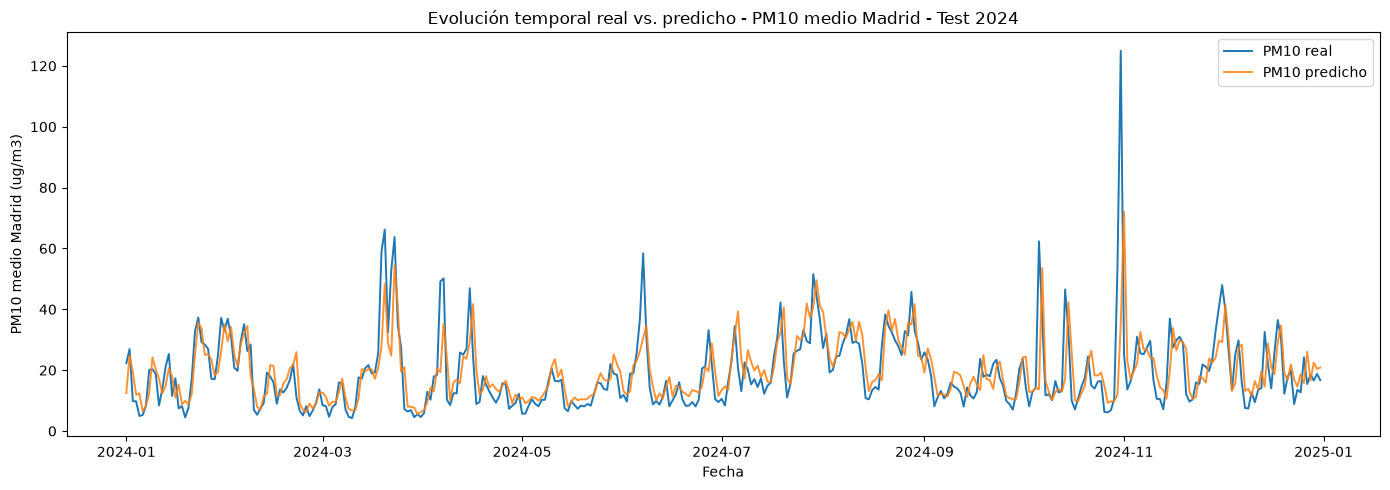

In [30]:
# ============================================================
# EVOLUCIÓN TEMPORAL - MEDIA DIARIA DE MADRID
# ============================================================

serie = (
    evaluacion.groupby("fecha")
    .agg(real=("contaminante_t", "mean"), predicho=("prediccion", "mean"))
    .reset_index()
)

plt.figure(figsize=(14, 5))
plt.plot(serie["fecha"], serie["real"], label="PM10 real", lw=1.4)
plt.plot(serie["fecha"], serie["predicho"], label="PM10 predicho", lw=1.4, alpha=0.85)
plt.xlabel("Fecha")
plt.ylabel("PM10 medio Madrid (ug/m3)")
plt.title("Evolución temporal real vs. predicho - PM10 medio Madrid - Test 2024")
plt.legend()
plt.tight_layout()
plt.show()

## 19. Interpretación mediante SHAP

`beeswarm` sobre el modelo final: qué variables influyen más en la predicción y
en qué dirección. Es el segundo y último gráfico acordado con el equipo.

SHAP: (3000, 32)


,shap_medio_abs
PM10_t,7.3872
PM2.5_madrid_lag1,2.2152
PM10_ma3,1.0855
PM2.5_madrid_t,0.8734
viento_racha_t,0.7550
presion_min_t,0.6770
es_laborable,0.6667
PM2.5_madrid_ma3,0.5720
NO2_madrid_lag1,0.5389
NO2_madrid_t,0.5285


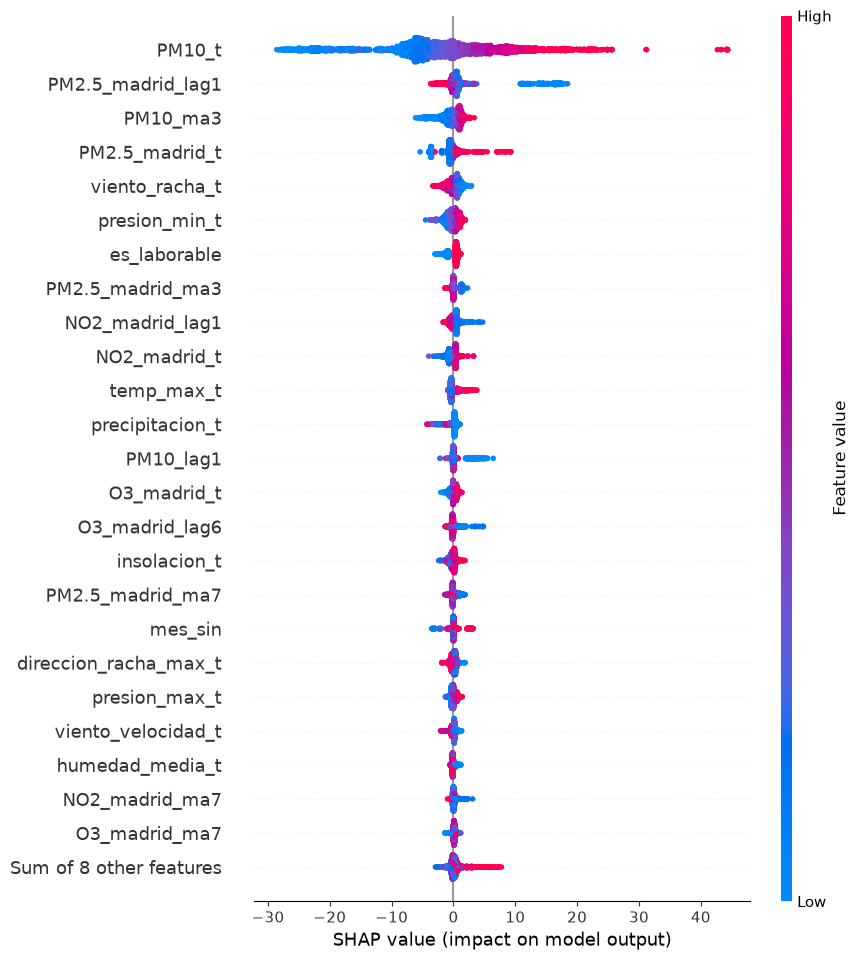

In [31]:
# ============================================================
# VALORES SHAP + BEESWARM
# ============================================================

import shap

n_shap = min(3000, len(X_te_final))
X_shap = X_te_final.sample(n=n_shap, random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(modelo_final)
shap_values = explainer(X_shap)
print("SHAP:", shap_values.values.shape)

# Importancia media (tabla, sin gráfico)
shap_imp = (
    pd.Series(np.abs(shap_values.values).mean(axis=0), index=FEATURES_FINAL)
    .sort_values(ascending=False)
)
display(shap_imp.round(4).to_frame("shap_medio_abs"))

shap.plots.beeswarm(shap_values, max_display=min(25, len(FEATURES_FINAL)))

## 20. Conclusiones

**Escenario.** Se predice el PM10 medio diario del día `T + 1` en cada estación
con información observada hasta el cierre del día `T`: histórico del propio PM10,
meteorología y contexto de otros contaminantes en `T` / `T - 1` / `T - 6` (medias
móviles terminadas en `T`), y calendario del propio día objetivo `T + 1`. Es una
**previsión a un día vista**.

**Datos.** 13 estaciones de PM10, 2020-2024, serie diaria continua y sin nulos.
Tras generar retardos y medias móviles y eliminar el arranque de las series
quedan **23.660 filas**. Partición temporal: entrenamiento <= 2022 (14.157),
validación 2023 (4.745), test 2024 (4.758).

**Selección del modelo.** Búsqueda de hiperparámetros con *early stopping* contra
2023 (`max_depth = 7`, `learning_rate = 0.03`, `subsample = 1.0`,
`colsample_bytree = 0.8`), eliminación progresiva de variables (**41 -> 32**: se
van tipo de estación, latitud, longitud, altitud, `PM10_lag6`, `PM10_ma7`,
`humedad_min_t` y `PM2.5_madrid_lag6`) y segunda rejilla de regularización
(`reg_alpha = 0`, `reg_lambda = 1`, `min_child_weight = 1`, `gamma = 0.5`). El
modelo final se reentrena con 2020-2023 y **155 árboles**.

**Resultado sobre test 2024** (evaluación única):

| Métrica | Modelo final | Baseline persistencia T |
|---|--:|--:|
| MAE | **6.03** | 6.92 |
| RMSE | **10.01** | 11.82 |
| R2 | **0.448** | 0.230 |
| Sesgo medio | +0.54 | -0.01 |

XGBoost reduce el **MAE un 12.9 %** y el **RMSE un 15.3 %** frente a la
persistencia, y dobla el R2 (0.23 -> 0.45). El MAE equivale al **31.6 %** de la
concentración media de 2024 (~19.1 ug/m3). El modelo presenta un **sesgo
positivo de +0.54 ug/m3** (sobreestima ligeramente de media), frente a la
persistencia que es prácticamente insesgada.

**Por nivel de concentración.** El error se concentra en los episodios altos: el
modelo ajusta bien los días limpios (MAE ~ 4-5 ug/m3 por debajo de 25) pero
**infraestima con fuerza los picos** - sesgo de -25 ug/m3 en el rango 50-70 y de
-60 ug/m3 por encima de 70 (29 observaciones, intrusiones de polvo sahariano).
Para valores reales de 58-98 ug/m3 el modelo predice de media 33-38. También
**sobreestima los días muy bajos** (sesgo +3.7 en el rango 0-15). Es el
comportamiento típico de regresión hacia la media con eventos extremos poco
frecuentes.

**Por estación.** MAE entre **4.83** (Plaza Elíptica) y **6.89 ug/m3** (Puente de
Vallecas); R2 entre 0.32 y 0.50. Los sesgos por estación son pequeños salvo
Farolillo (-1.64). **No hay diferencia sistemática tráfico / fondo**: la mejor
estación es de tráfico y la peor de fondo.

**Imputación IDW.** En test 2024 solo 7 observaciones proceden de imputación
espacial (MAE 7.51 vs 6.03 en las medidas reales). La correlación por estación
entre porcentaje de imputación y MAE es 0.38, positiva pero débil y poco robusta
con tan pocos casos. No se aprecia una distorsión sistemática atribuible a la
imputación.

**SHAP.** La variable dominante es `PM10_t` (SHAP medio 7.39), con mucha
diferencia sobre el resto. Le sigue el **bloque de PM2.5 de Madrid**
(`PM2.5_madrid_lag1` 2.22, `PM2.5_madrid_t` 0.87, `PM2.5_madrid_ma3` 0.57), y
después `PM10_ma3` (1.09), variables meteorológicas de `T` (`viento_racha_t`
0.76, `presion_min_t` 0.68) y `es_laborable` (0.67). Aunque PM2.5 y PM10 están
muy correlacionados, el contexto de PM2.5 aporta señal propia - probablemente
por distinguir días de fracción fina de episodios de fracción gruesa.


In [32]:
# ============================================================
# GUARDADO DEL MODELO Y LAS VARIABLES
# ============================================================

import joblib

MODEL_DIR = ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(modelo_final, MODEL_DIR / f"xgboost_{PREF}_final.joblib")
joblib.dump(
    {"features": FEATURES_FINAL,
     "escenario": "target T+1; observado hasta T (horizonte de 1 dia)",
     "params": PARAMS_FINAL, "n_arboles": N_ARBOLES_FINAL},
    MODEL_DIR / f"features_{PREF}_final.joblib",
)

print("Guardado en", MODEL_DIR)
print("Features finales:", len(FEATURES_FINAL))

Guardado en c:\Users\evagd\OneDrive\Documentos\Master\TFM\Report\TFM\models
Features finales: 32


In [33]:
con.close()